# Dispersion-Assisted Optical Phase Recovery
## Paper-Level Colab Notebook for Carrier-Less Optical Reception

This notebook implements a **time-domain Gerchberg–Saxton phase-recovery pipeline** inspired by the original Gerchberg–Saxton method and its adaptation to dispersive Fourier transform measurements.

### What this notebook does
- Builds a physically interpretable complex optical waveform
- Simulates **two dispersive intensity-only measurements**
- Implements a **dual-dispersion GS loop**
- Tracks convergence and reconstruction error
- Studies **dispersion diversity**, **noise**, and **ADC quantization**
- Provides a communication-style extension for symbol-bearing waveforms
- Includes a lightweight **PyTorch** scaffold for future GS-vs-AI comparisons

### Suggested repo positioning
This is suitable as:
- a final class Colab notebook,
- the main simulation artifact for a GitHub repository,
- the foundation for presentation figures and sensitivity plots.

---


## 1. Imports and plotting style


In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11

rng = np.random.default_rng(7)


## 2. Physical model

We represent the complex optical field in time as

\[
E(t) = A(t)e^{j\phi(t)}.
\]

To model propagation through a dispersive element, we work in the frequency domain and apply a quadratic phase transfer function

\[
H(\omega) = \exp\!\left(-\frac{j}{2}\beta_2L\,\omega^2\right).
\]

This gives a compact, simulation-friendly model of dispersion-assisted measurement.


In [2]:
def centered_fft(x):
    return np.fft.fftshift(np.fft.fft(np.fft.ifftshift(x)))

def centered_ifft(X):
    return np.fft.fftshift(np.fft.ifft(np.fft.ifftshift(X)))

def omega_grid(n, dt):
    return 2 * np.pi * np.fft.fftshift(np.fft.fftfreq(n, d=dt))

def dispersion_transfer(omega, beta2L):
    return np.exp(-0.5j * beta2L * omega**2)

def propagate_dispersion(field_t, dt, beta2L):
    w = omega_grid(field_t.size, dt)
    H = dispersion_transfer(w, beta2L)
    return centered_ifft(centered_fft(field_t) * H)

def add_awgn_real(x, snr_db, rng):
    power = np.mean(np.abs(x)**2)
    sigma2 = power / (10**(snr_db / 10))
    noise = rng.normal(scale=np.sqrt(sigma2), size=x.shape)
    return x + noise

def quantize_uniform(x, bits):
    x = np.asarray(x)
    xmin, xmax = np.min(x), np.max(x)
    if xmax == xmin:
        return x.copy()
    levels = 2**bits
    x_norm = (x - xmin) / (xmax - xmin)
    xq = np.round(x_norm * (levels - 1)) / (levels - 1)
    return xq * (xmax - xmin) + xmin

def rmse(x, y):
    return np.sqrt(np.mean(np.abs(x - y)**2))

def align_phase(phi_ref, phi_est):
    offset = np.mean(phi_ref - phi_est)
    return phi_est + offset


## 3. Synthetic optical waveform

We start with a pulse that has:
- a Gaussian envelope,
- controlled quadratic chirp,
- optional phase ripple.

This gives a nontrivial test case without making the notebook brittle.


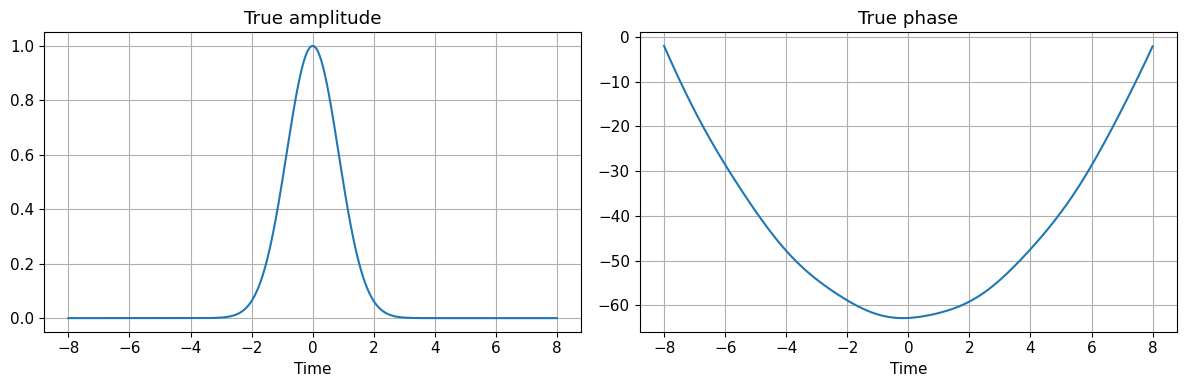

In [3]:
def gaussian_chirped_pulse(t, sigma=0.75, chirp=1.2, center=0.0, ripple=0.12, ripple_freq=2.5):
    tau = t - center
    envelope = np.exp(-0.5 * (tau / sigma)**2)
    phase = chirp * tau**2 + ripple * np.sin(ripple_freq * tau)
    return envelope * np.exp(1j * phase)

n = 2048
t_max = 8.0
t = np.linspace(-t_max, t_max, n)
dt = t[1] - t[0]

field_true = gaussian_chirped_pulse(t, sigma=0.85, chirp=0.95, ripple=0.18, ripple_freq=2.0)
amp_true = np.abs(field_true)
phase_true = np.unwrap(np.angle(field_true))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(t, amp_true)
ax[0].set_title("True amplitude")
ax[0].set_xlabel("Time")
ax[1].plot(t, phase_true)
ax[1].set_title("True phase")
ax[1].set_xlabel("Time")
plt.tight_layout()
plt.show()


## 4. Dual-dispersion measurement model

Following the dispersive phase-recovery idea, we form **two temporal measurements** after propagation through two different dispersion values.

A key lesson is that the two measurements need enough **diversity**. If the dispersion values are too similar, recovery quality usually degrades.


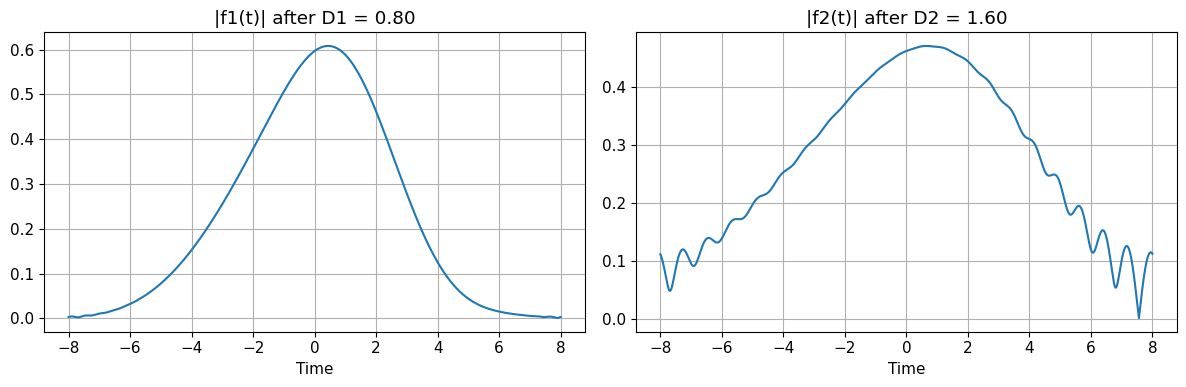

In [4]:
beta2L_1 = 0.8
beta2L_2 = 1.6

plane1_true = propagate_dispersion(field_true, dt, beta2L_1)
plane2_true = propagate_dispersion(field_true, dt, beta2L_2)

mag1_clean = np.abs(plane1_true)
mag2_clean = np.abs(plane2_true)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(t, mag1_clean)
ax[0].set_title(f"|f1(t)| after D1 = {beta2L_1:.2f}")
ax[0].set_xlabel("Time")
ax[1].plot(t, mag2_clean)
ax[1].set_title(f"|f2(t)| after D2 = {beta2L_2:.2f}")
ax[1].set_xlabel("Time")
plt.tight_layout()
plt.show()


## 5. Noise and ADC model

To make the study closer to a real receiver pipeline, we allow:
- additive real measurement noise on the intensity envelope,
- finite-bit quantization.

This is especially useful for sensitivity plots and for connecting to the measurement limitations discussed in high-speed time-stretch systems.


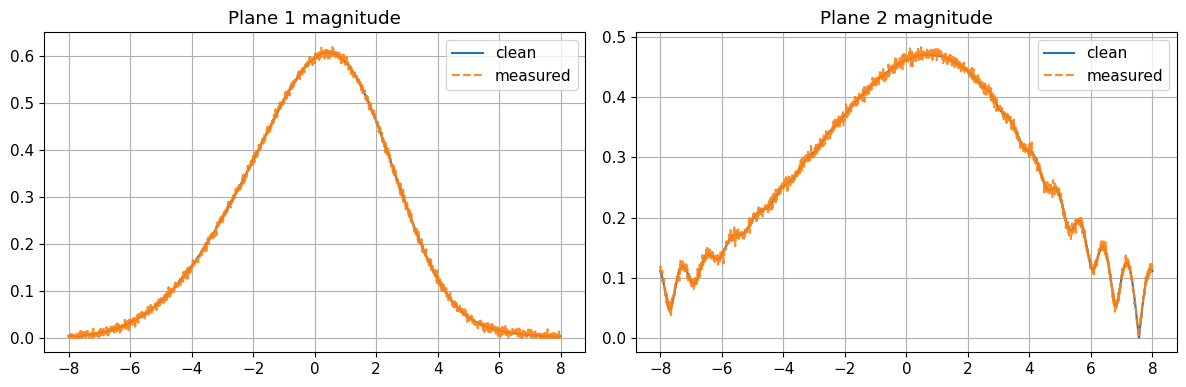

In [5]:
snr_db = 35
adc_bits = 10

mag1_meas = quantize_uniform(np.clip(add_awgn_real(mag1_clean, snr_db, rng), 0, None), adc_bits)
mag2_meas = quantize_uniform(np.clip(add_awgn_real(mag2_clean, snr_db, rng), 0, None), adc_bits)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(t, mag1_clean, label="clean")
ax[0].plot(t, mag1_meas, "--", label="measured", alpha=0.9)
ax[0].set_title("Plane 1 magnitude")
ax[0].legend()
ax[1].plot(t, mag2_clean, label="clean")
ax[1].plot(t, mag2_meas, "--", label="measured", alpha=0.9)
ax[1].set_title("Plane 2 magnitude")
ax[1].legend()
plt.tight_layout()
plt.show()


## 6. Time-domain Gerchberg–Saxton recovery

This implementation alternates between the two dispersive planes:

1. start with the measured magnitude in plane 1 and an initial phase guess,
2. invert the first dispersion to estimate the input plane,
3. apply the second dispersion to estimate plane 2,
4. replace the plane-2 magnitude by the measured magnitude,
5. invert the second dispersion,
6. reapply the first dispersion,
7. replace the plane-1 magnitude,
8. repeat.

We also track:
- plane-1 magnitude mismatch,
- plane-2 magnitude mismatch,
- recovered input-plane amplitude and phase errors.


In [6]:
def gs_dual_dispersion(
    mag1,
    mag2,
    dt,
    beta2L_1,
    beta2L_2,
    iterations=80,
    init="chirped",
    seed=7,
    field_ref=None,
):
    rng = np.random.default_rng(seed)

    if init == "random":
        phase0 = rng.uniform(-np.pi, np.pi, size=mag1.shape)
    elif init == "flat":
        phase0 = np.zeros_like(mag1)
    elif init == "chirped":
        x = np.linspace(-1, 1, mag1.size)
        phase0 = 2.0 * np.pi * 0.35 * x**2
    else:
        raise ValueError("init must be one of: random, flat, chirped")

    plane1_est = mag1 * np.exp(1j * phase0)

    history = {
        "err_plane1": [],
        "err_plane2": [],
        "err_amp_input": [],
        "err_phase_input": [],
    }

    for _ in range(iterations):
        # Plane 1 -> input
        input_est = propagate_dispersion(plane1_est, dt, -beta2L_1)

        # Input -> plane 2
        plane2_est = propagate_dispersion(input_est, dt, beta2L_2)

        # Plane 2 amplitude replacement
        err2 = rmse(np.abs(plane2_est), mag2)
        plane2_est = mag2 * np.exp(1j * np.angle(plane2_est))

        # Plane 2 -> input
        input_est = propagate_dispersion(plane2_est, dt, -beta2L_2)

        # Input -> plane 1
        plane1_est = propagate_dispersion(input_est, dt, beta2L_1)

        # Plane 1 amplitude replacement
        err1 = rmse(np.abs(plane1_est), mag1)
        plane1_est = mag1 * np.exp(1j * np.angle(plane1_est))

        history["err_plane1"].append(err1)
        history["err_plane2"].append(err2)

        if field_ref is not None:
            input_rec = propagate_dispersion(plane1_est, dt, -beta2L_1)
            amp_ref = np.abs(field_ref)
            amp_rec = np.abs(input_rec)

            phi_ref = np.unwrap(np.angle(field_ref))
            phi_rec = np.unwrap(np.angle(input_rec))
            phi_rec = align_phase(phi_ref, phi_rec)

            history["err_amp_input"].append(rmse(amp_ref, amp_rec))
            history["err_phase_input"].append(rmse(phi_ref, phi_rec))

    field_rec = propagate_dispersion(plane1_est, dt, -beta2L_1)
    return field_rec, history

field_rec, history = gs_dual_dispersion(
    mag1_meas,
    mag2_meas,
    dt,
    beta2L_1,
    beta2L_2,
    iterations=100,
    init="chirped",
    seed=3,
    field_ref=field_true,
)


## 7. Convergence plots


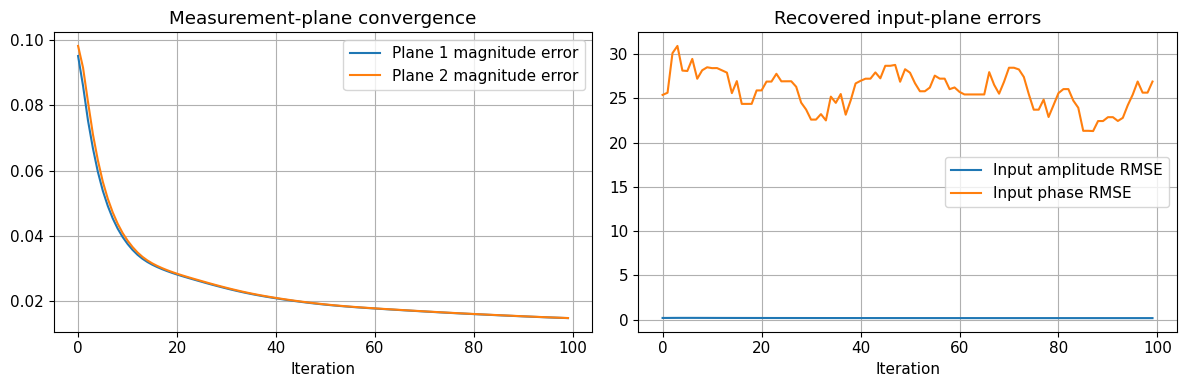

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(history["err_plane1"], label="Plane 1 magnitude error")
ax[0].plot(history["err_plane2"], label="Plane 2 magnitude error")
ax[0].set_title("Measurement-plane convergence")
ax[0].set_xlabel("Iteration")
ax[0].legend()

ax[1].plot(history["err_amp_input"], label="Input amplitude RMSE")
ax[1].plot(history["err_phase_input"], label="Input phase RMSE")
ax[1].set_title("Recovered input-plane errors")
ax[1].set_xlabel("Iteration")
ax[1].legend()

plt.tight_layout()
plt.show()


## 8. Recovered field quality


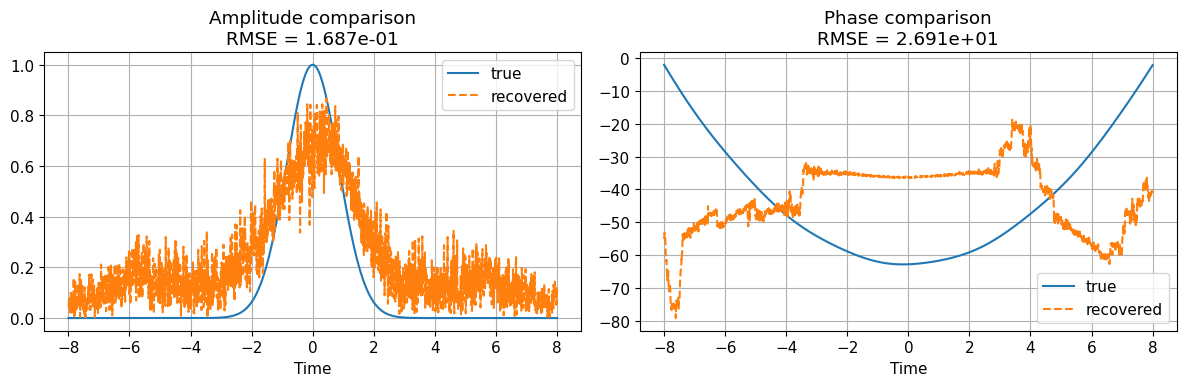

Final amplitude RMSE: 1.687077e-01
Final phase RMSE:     2.691249e+01


In [8]:
amp_rec = np.abs(field_rec)
phase_rec = np.unwrap(np.angle(field_rec))
phase_rec_aligned = align_phase(phase_true, phase_rec)

amplitude_rmse = rmse(amp_true, amp_rec)
phase_rmse = rmse(phase_true, phase_rec_aligned)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(t, amp_true, label="true")
ax[0].plot(t, amp_rec, "--", label="recovered")
ax[0].set_title(f"Amplitude comparison\nRMSE = {amplitude_rmse:.3e}")
ax[0].set_xlabel("Time")
ax[0].legend()

ax[1].plot(t, phase_true, label="true")
ax[1].plot(t, phase_rec_aligned, "--", label="recovered")
ax[1].set_title(f"Phase comparison\nRMSE = {phase_rmse:.3e}")
ax[1].set_xlabel("Time")
ax[1].legend()

plt.tight_layout()
plt.show()

print(f"Final amplitude RMSE: {amplitude_rmse:.6e}")
print(f"Final phase RMSE:     {phase_rmse:.6e}")


## 9. Spectral reconstruction view

The temporal GS algorithm is often evaluated through the reconstructed spectrum. We therefore compare the magnitude spectra of the true and recovered input fields.


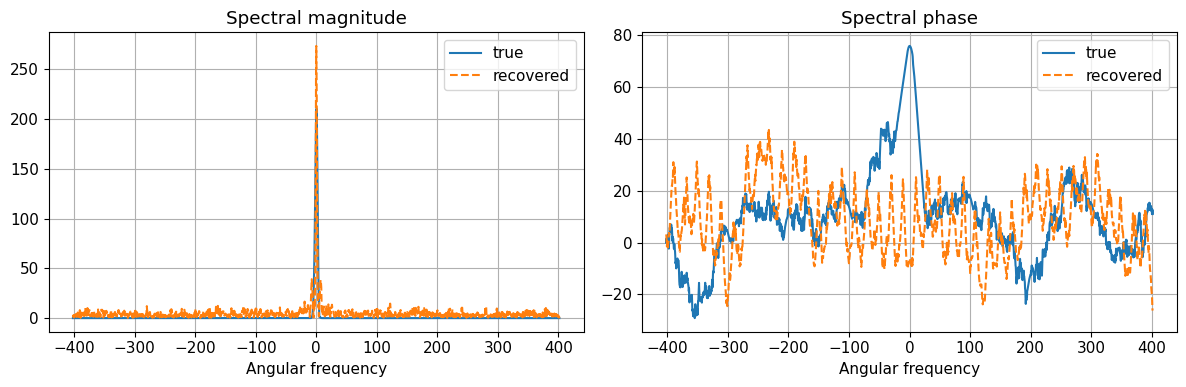

In [9]:
w = omega_grid(n, dt)
spec_true = centered_fft(field_true)
spec_rec = centered_fft(field_rec)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(w, np.abs(spec_true), label="true")
ax[0].plot(w, np.abs(spec_rec), "--", label="recovered")
ax[0].set_title("Spectral magnitude")
ax[0].set_xlabel("Angular frequency")
ax[0].legend()

ax[1].plot(w, np.unwrap(np.angle(spec_true)), label="true")
ax[1].plot(w, np.unwrap(np.angle(spec_rec)), "--", label="recovered")
ax[1].set_title("Spectral phase")
ax[1].set_xlabel("Angular frequency")
ax[1].legend()

plt.tight_layout()
plt.show()


## 10. Dispersion-diversity sweep

A strong paper-style figure is a **dispersion-pair sweep**. Here we vary \(D_1\) and \(D_2\) and map reconstruction error. This directly shows the importance of diversity between the two measurement planes.


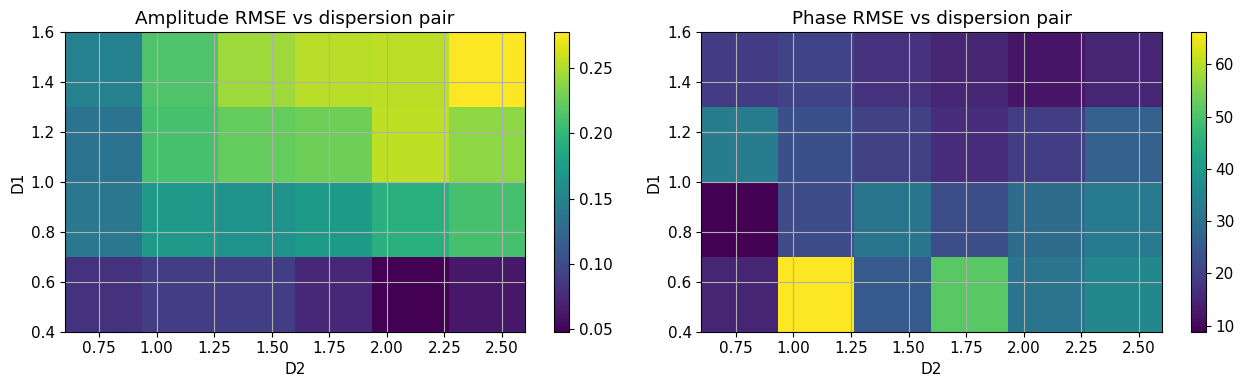

In [10]:
D1_vals = np.array([0.4, 0.8, 1.2, 1.6])
D2_vals = np.array([0.6, 1.0, 1.4, 1.8, 2.2, 2.6])

amp_err_map = np.zeros((len(D1_vals), len(D2_vals)))
phase_err_map = np.zeros((len(D1_vals), len(D2_vals)))

for i, d1 in enumerate(D1_vals):
    for j, d2 in enumerate(D2_vals):
        p1 = propagate_dispersion(field_true, dt, d1)
        p2 = propagate_dispersion(field_true, dt, d2)

        m1 = quantize_uniform(np.clip(add_awgn_real(np.abs(p1), snr_db, rng), 0, None), adc_bits)
        m2 = quantize_uniform(np.clip(add_awgn_real(np.abs(p2), snr_db, rng), 0, None), adc_bits)

        rec_field, _hist = gs_dual_dispersion(
            m1, m2, dt, d1, d2,
            iterations=60,
            init="chirped",
            seed=11,
            field_ref=field_true,
        )

        amp_tmp = np.abs(rec_field)
        phi_tmp = np.unwrap(np.angle(rec_field))
        phi_tmp = align_phase(phase_true, phi_tmp)

        amp_err_map[i, j] = rmse(amp_true, amp_tmp)
        phase_err_map[i, j] = rmse(phase_true, phi_tmp)

fig, ax = plt.subplots(1, 2, figsize=(13, 4))

im0 = ax[0].imshow(
    amp_err_map, origin="lower", aspect="auto",
    extent=[D2_vals.min(), D2_vals.max(), D1_vals.min(), D1_vals.max()]
)
ax[0].set_title("Amplitude RMSE vs dispersion pair")
ax[0].set_xlabel("D2")
ax[0].set_ylabel("D1")
plt.colorbar(im0, ax=ax[0])

im1 = ax[1].imshow(
    phase_err_map, origin="lower", aspect="auto",
    extent=[D2_vals.min(), D2_vals.max(), D1_vals.min(), D1_vals.max()]
)
ax[1].set_title("Phase RMSE vs dispersion pair")
ax[1].set_xlabel("D2")
ax[1].set_ylabel("D1")
plt.colorbar(im1, ax=ax[1])

plt.tight_layout()
plt.show()


## 11. Iteration-count sweep

The original GS method is iterative, and recovery quality depends on the number of passes through the constraint loop. This section quantifies that tradeoff.


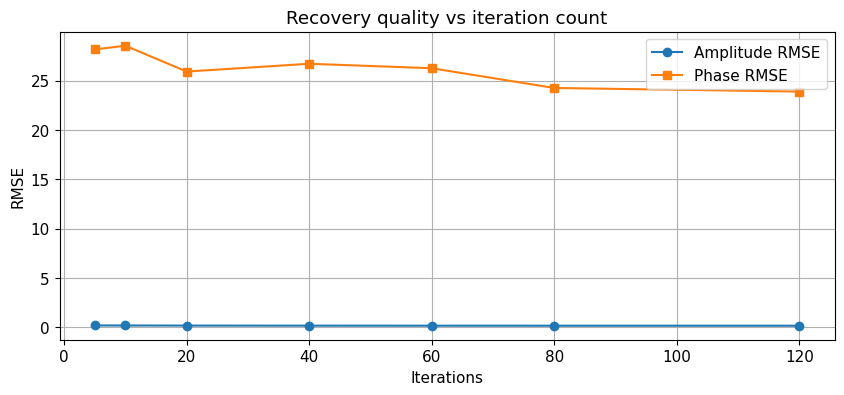

In [11]:
iter_vals = [5, 10, 20, 40, 60, 80, 120]
amp_curve = []
phase_curve = []

for it in iter_vals:
    rec_field, _hist = gs_dual_dispersion(
        mag1_meas,
        mag2_meas,
        dt,
        beta2L_1,
        beta2L_2,
        iterations=it,
        init="chirped",
        seed=4,
        field_ref=field_true,
    )
    a = np.abs(rec_field)
    p = np.unwrap(np.angle(rec_field))
    p = align_phase(phase_true, p)
    amp_curve.append(rmse(amp_true, a))
    phase_curve.append(rmse(phase_true, p))

plt.plot(iter_vals, amp_curve, "o-", label="Amplitude RMSE")
plt.plot(iter_vals, phase_curve, "s-", label="Phase RMSE")
plt.xlabel("Iterations")
plt.ylabel("RMSE")
plt.title("Recovery quality vs iteration count")
plt.legend()
plt.show()


## 12. Noise sensitivity sweep

This section studies the effect of measurement noise. The goal is not to claim a universal threshold, but to map the degradation trend and generate a slide-friendly figure.


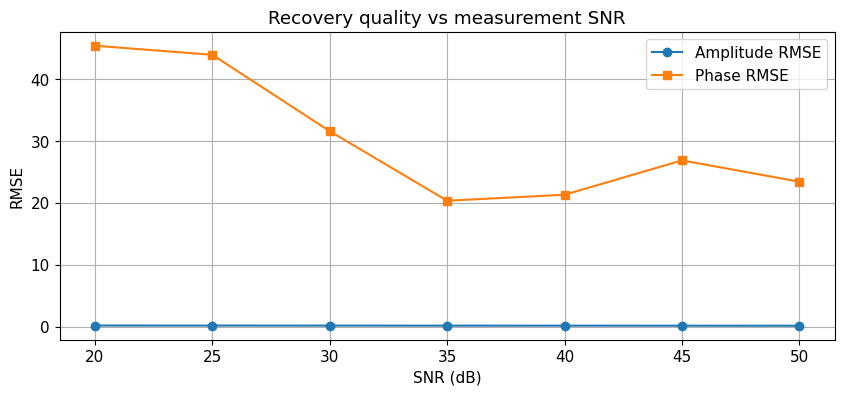

In [12]:
snr_vals = [20, 25, 30, 35, 40, 45, 50]
amp_vs_snr = []
phase_vs_snr = []

for snr in snr_vals:
    m1 = quantize_uniform(np.clip(add_awgn_real(mag1_clean, snr, rng), 0, None), adc_bits)
    m2 = quantize_uniform(np.clip(add_awgn_real(mag2_clean, snr, rng), 0, None), adc_bits)

    rec_field, _hist = gs_dual_dispersion(
        m1, m2, dt, beta2L_1, beta2L_2,
        iterations=80,
        init="chirped",
        seed=5,
        field_ref=field_true,
    )

    a = np.abs(rec_field)
    p = np.unwrap(np.angle(rec_field))
    p = align_phase(phase_true, p)

    amp_vs_snr.append(rmse(amp_true, a))
    phase_vs_snr.append(rmse(phase_true, p))

plt.plot(snr_vals, amp_vs_snr, "o-", label="Amplitude RMSE")
plt.plot(snr_vals, phase_vs_snr, "s-", label="Phase RMSE")
plt.xlabel("SNR (dB)")
plt.ylabel("RMSE")
plt.title("Recovery quality vs measurement SNR")
plt.legend()
plt.show()


## 13. ADC quantization sweep

Digitizer resolution can become a bottleneck in high-speed measurements. Here we quantify the sensitivity of the recovery loop to finite-bit amplitude measurements.


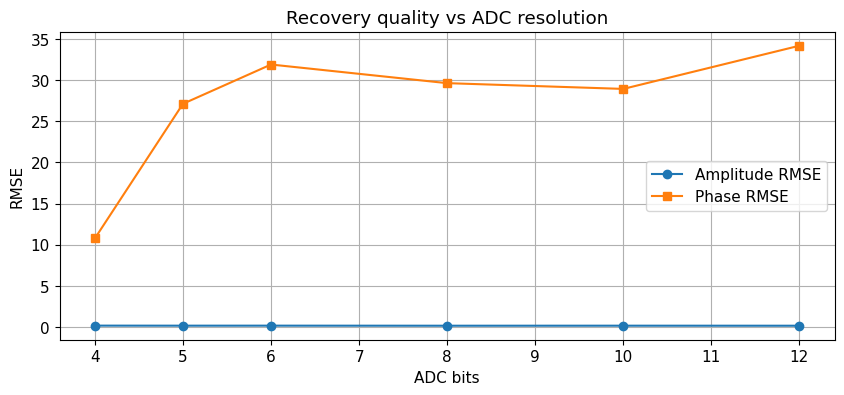

In [13]:
bit_vals = [4, 5, 6, 8, 10, 12]
amp_vs_bits = []
phase_vs_bits = []

for bits in bit_vals:
    m1 = quantize_uniform(np.clip(add_awgn_real(mag1_clean, snr_db, rng), 0, None), bits)
    m2 = quantize_uniform(np.clip(add_awgn_real(mag2_clean, snr_db, rng), 0, None), bits)

    rec_field, _hist = gs_dual_dispersion(
        m1, m2, dt, beta2L_1, beta2L_2,
        iterations=80,
        init="chirped",
        seed=6,
        field_ref=field_true,
    )

    a = np.abs(rec_field)
    p = np.unwrap(np.angle(rec_field))
    p = align_phase(phase_true, p)

    amp_vs_bits.append(rmse(amp_true, a))
    phase_vs_bits.append(rmse(phase_true, p))

plt.plot(bit_vals, amp_vs_bits, "o-", label="Amplitude RMSE")
plt.plot(bit_vals, phase_vs_bits, "s-", label="Phase RMSE")
plt.xlabel("ADC bits")
plt.ylabel("RMSE")
plt.title("Recovery quality vs ADC resolution")
plt.legend()
plt.show()


## 14. Communication-style extension

The course brief asks for eventual simulation with optical communication data. The block below provides a compact symbol-bearing waveform generator that can later replace the single pulse test case.


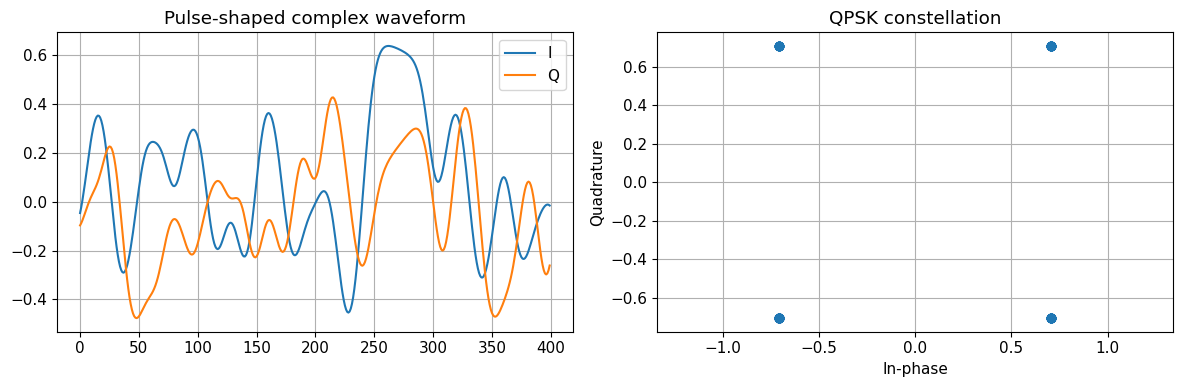

In [14]:
def qpsk_symbols(n_symbols, rng):
    const = np.array([1+1j, 1-1j, -1+1j, -1-1j], dtype=complex) / np.sqrt(2)
    return const[rng.integers(0, len(const), size=n_symbols)]

def upsample(symbols, sps):
    x = np.zeros(len(symbols) * sps, dtype=complex)
    x[::sps] = symbols
    return x

def gaussian_pulse_shape(num_taps=81, sigma=9.0):
    n = np.arange(num_taps) - (num_taps - 1) / 2
    h = np.exp(-0.5 * (n / sigma)**2)
    h /= np.linalg.norm(h)
    return h

def shaped_waveform(symbols, sps=8, num_taps=81, phase_ramp=0.02):
    x = upsample(symbols, sps)
    h = gaussian_pulse_shape(num_taps=num_taps, sigma=sps)
    y = np.convolve(x, h, mode="same")
    n = np.arange(y.size)
    y *= np.exp(1j * phase_ramp * n)
    return y

symbols = qpsk_symbols(64, rng)
wave = shaped_waveform(symbols, sps=8, num_taps=81, phase_ramp=0.01)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(np.real(wave[:400]), label="I")
ax[0].plot(np.imag(wave[:400]), label="Q")
ax[0].set_title("Pulse-shaped complex waveform")
ax[0].legend()

ax[1].plot(np.real(symbols), np.imag(symbols), "o")
ax[1].set_title("QPSK constellation")
ax[1].set_xlabel("In-phase")
ax[1].set_ylabel("Quadrature")
ax[1].axis("equal")

plt.tight_layout()
plt.show()


## 15. PyTorch scaffold for future GS-vs-AI work

A later extension can compare:
- classical iterative GS,
- Hilbert / Fourier-style baselines,
- neural regression.

This cell is intentionally lightweight and safe for GitHub.


In [15]:
try:
    import torch

    device = "cuda" if torch.cuda.is_available() else "cpu"
    x = torch.tensor(np.stack([np.real(wave), np.imag(wave)], axis=0), dtype=torch.float32, device=device)

    print("PyTorch available:", True)
    print("Device:", device)
    print("Example tensor shape:", tuple(x.shape))
except Exception as exc:
    print("PyTorch available:", False)
    print(exc)


PyTorch available: True
Device: cuda
Example tensor shape: (2, 512)


## 16. Discussion notes for the report or slides

### Key claims this notebook can support
- Two dispersive intensity measurements can be used for phase recovery.
- Dispersion diversity matters.
- Recovery improves with iteration count, up to a practical limit.
- Noise and quantization degrade performance in measurable ways.
- The framework is ready for communication-bearing waveforms and future GS-vs-AI comparisons.

### Recommended slide figures
1. True amplitude / phase of the test field
2. Two measured intensity traces after \(D_1\) and \(D_2\)
3. GS convergence curves
4. Recovered-vs-true phase plot
5. Dispersion-pair heatmap
6. SNR sensitivity curve
7. ADC-bit sensitivity curve

### Suggested branch name
`feature/paper-level-phase-recovery-notebook`
